In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier

In [2]:
data = pd.read_csv("dataset4.csv")

In [3]:
print(data.shape)
print(data.columns)
print(data.info())
print(data.describe())

(10000, 30)
Index(['video_id', 'category', 'region', 'language', 'duration_seconds',
       'creator_followers', 'creator_total_likes', 'creator_verified',
       'account_age_days', 'upload_hour', 'upload_weekday', 'hashtags_count',
       'caption_length', 'sound_popularity', 'effect_used',
       'posting_frequency_week', 'views', 'unique_viewers', 'likes',
       'comments', 'shares', 'favorites', 'profile_visits', 'watch_time_ratio',
       'completion_rate', 'engagement_rate', 'follower_view_ratio',
       'virality_score', 'trend_level', 'days_on_fyp'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   video_id                10000 non-null  object 
 1   category                10000 non-null  object 
 2   region                  10000 non-null  object 
 3   language                10000 non

In [4]:
print("\nMissing Values")
print(data.isnull().sum())


Missing Values
video_id                  0
category                  0
region                    0
language                  0
duration_seconds          0
creator_followers         0
creator_total_likes       0
creator_verified          0
account_age_days          0
upload_hour               0
upload_weekday            0
hashtags_count            0
caption_length            0
sound_popularity          0
effect_used               0
posting_frequency_week    0
views                     0
unique_viewers            0
likes                     0
comments                  0
shares                    0
favorites                 0
profile_visits            0
watch_time_ratio          0
completion_rate           0
engagement_rate           0
follower_view_ratio       0
virality_score            0
trend_level               0
days_on_fyp               0
dtype: int64


# Encoding

In [5]:
categorical_cols = [
    "category",
    "region",
    "language",
    "upload_weekday"
]

encoder = LabelEncoder()

for col in categorical_cols:
    data[col] = encoder.fit_transform(data[col])

# Feature Engineering

In [6]:
data["followers_per_post"] = (data["creator_followers"] /(data["posting_frequency_week"] + 1))

data["likes_per_view"] = (data["likes"] /(data["views"] + 1))

data["comments_per_view"] = (data["comments"] /(data["views"] + 1))

data["shares_per_view"] = (data["shares"] /(data["views"] + 1))

data["favorites_per_view"] = (data["favorites"] /(data["views"] + 1))

data["total_engagement"] = (data["likes"] +data["comments"] +data["shares"] +data["favorites"])

In [7]:
data["total_interactions"] = (data["likes"] +data["comments"] +data["shares"] +data["favorites"])

data["likes_per_comment"] = (data["likes"] /(data["comments"] + 1))

In [8]:
threshold = data["views"].quantile(0.75)

data["trend_fast"] = (
    data["views"] > threshold
).astype(int)

print(data[["views", "trend_fast"]].head())

    views  trend_fast
0   25979           0
1  191621           0
2  195929           0
3  195328           0
4  227367           0


# EDA


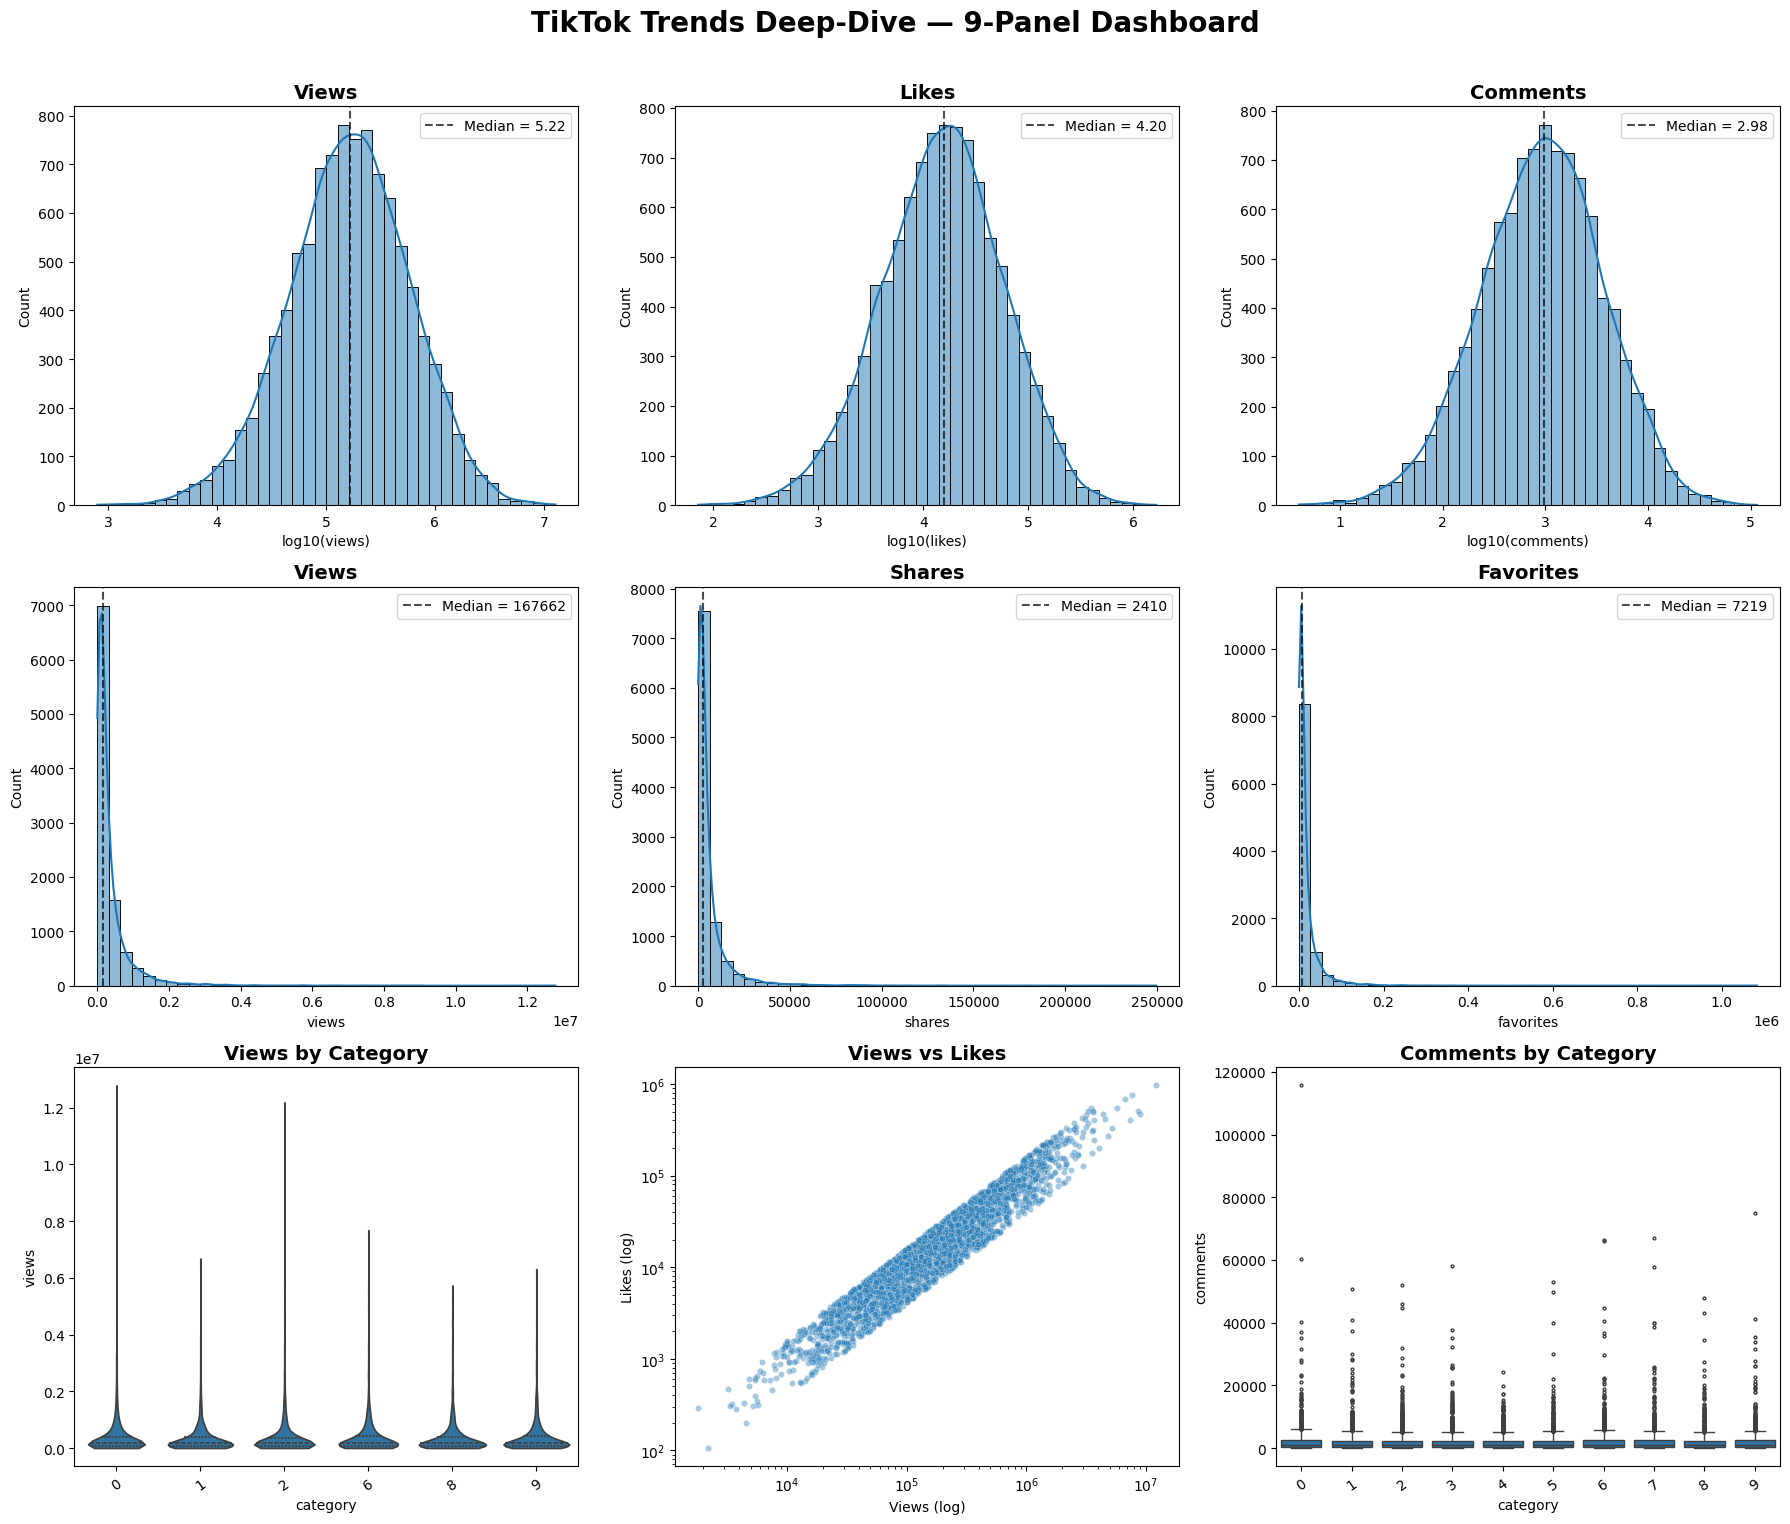

In [9]:
fig, axes = plt.subplots(3, 3, figsize=(18, 16))
fig.suptitle(
    "TikTok Trends Deep-Dive — 9-Panel Dashboard",
    fontsize=20,
    fontweight="bold",
    y=0.98
)

for i, col in enumerate(["views", "likes", "comments"]):
    log_data = np.log10(data[col].clip(lower=1))

    sns.histplot(
        log_data,
        bins=40,
        kde=True,
        ax=axes[0, i]
    )

    median_val = log_data.median()

    axes[0, i].axvline(
        median_val,
        color="black",
        linestyle="--",
        alpha=0.7,
        label=f"Median = {median_val:.2f}"
    )

    axes[0, i].set_title(col.replace("_", " ").title(), fontsize=14, fontweight="bold")
    axes[0, i].set_xlabel(f"log10({col})")
    axes[0, i].legend()
for i, col in enumerate(["views", "shares", "favorites"]):

    sns.histplot(
        data[col],
        bins=40,
        kde=True,
        ax=axes[1, i]
    )

    median_val = data[col].median()

    axes[1, i].axvline(
        median_val,
        color="black",
        linestyle="--",
        alpha=0.7,
        label=f"Median = {median_val:.0f}"
    )

    axes[1, i].set_title(col.replace("_", " ").title(), fontsize=14, fontweight="bold")
    axes[1, i].legend()

top_cats = data["category"].value_counts().head(6).index

sns.violinplot(
    data=data[data["category"].isin(top_cats)],
    x="category",
    y="views",
    inner="quartile",
    cut=0,
    ax=axes[2, 0]
)

axes[2, 0].set_title("Views by Category", fontsize=14, fontweight="bold")
axes[2, 0].tick_params(axis="x", rotation=35)

sample_df = data.sample(min(len(data), 3000), random_state=42)

sns.scatterplot(
    data=sample_df,
    x="views",
    y="likes",
    alpha=0.4,
    s=20,
    ax=axes[2, 1]
)

axes[2, 1].set_xscale("log")
axes[2, 1].set_yscale("log")
axes[2, 1].set_title("Views vs Likes", fontsize=14, fontweight="bold")
axes[2, 1].set_xlabel("Views (log)")
axes[2, 1].set_ylabel("Likes (log)")

sns.boxplot(
    data=data,
    x="category",
    y="comments",
    fliersize=2,
    ax=axes[2, 2]
)

axes[2, 2].set_title("Comments by Category", fontsize=14, fontweight="bold")
axes[2, 2].tick_params(axis="x", rotation=35)

plt.tight_layout(rect=[0, 0.03, 1, 0.97])

plt.show()

/var/folders/xz/jl0x7g45257404n2n3_cp3xh0000gn/T/ipykernel_3766/1325947985.py:131: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


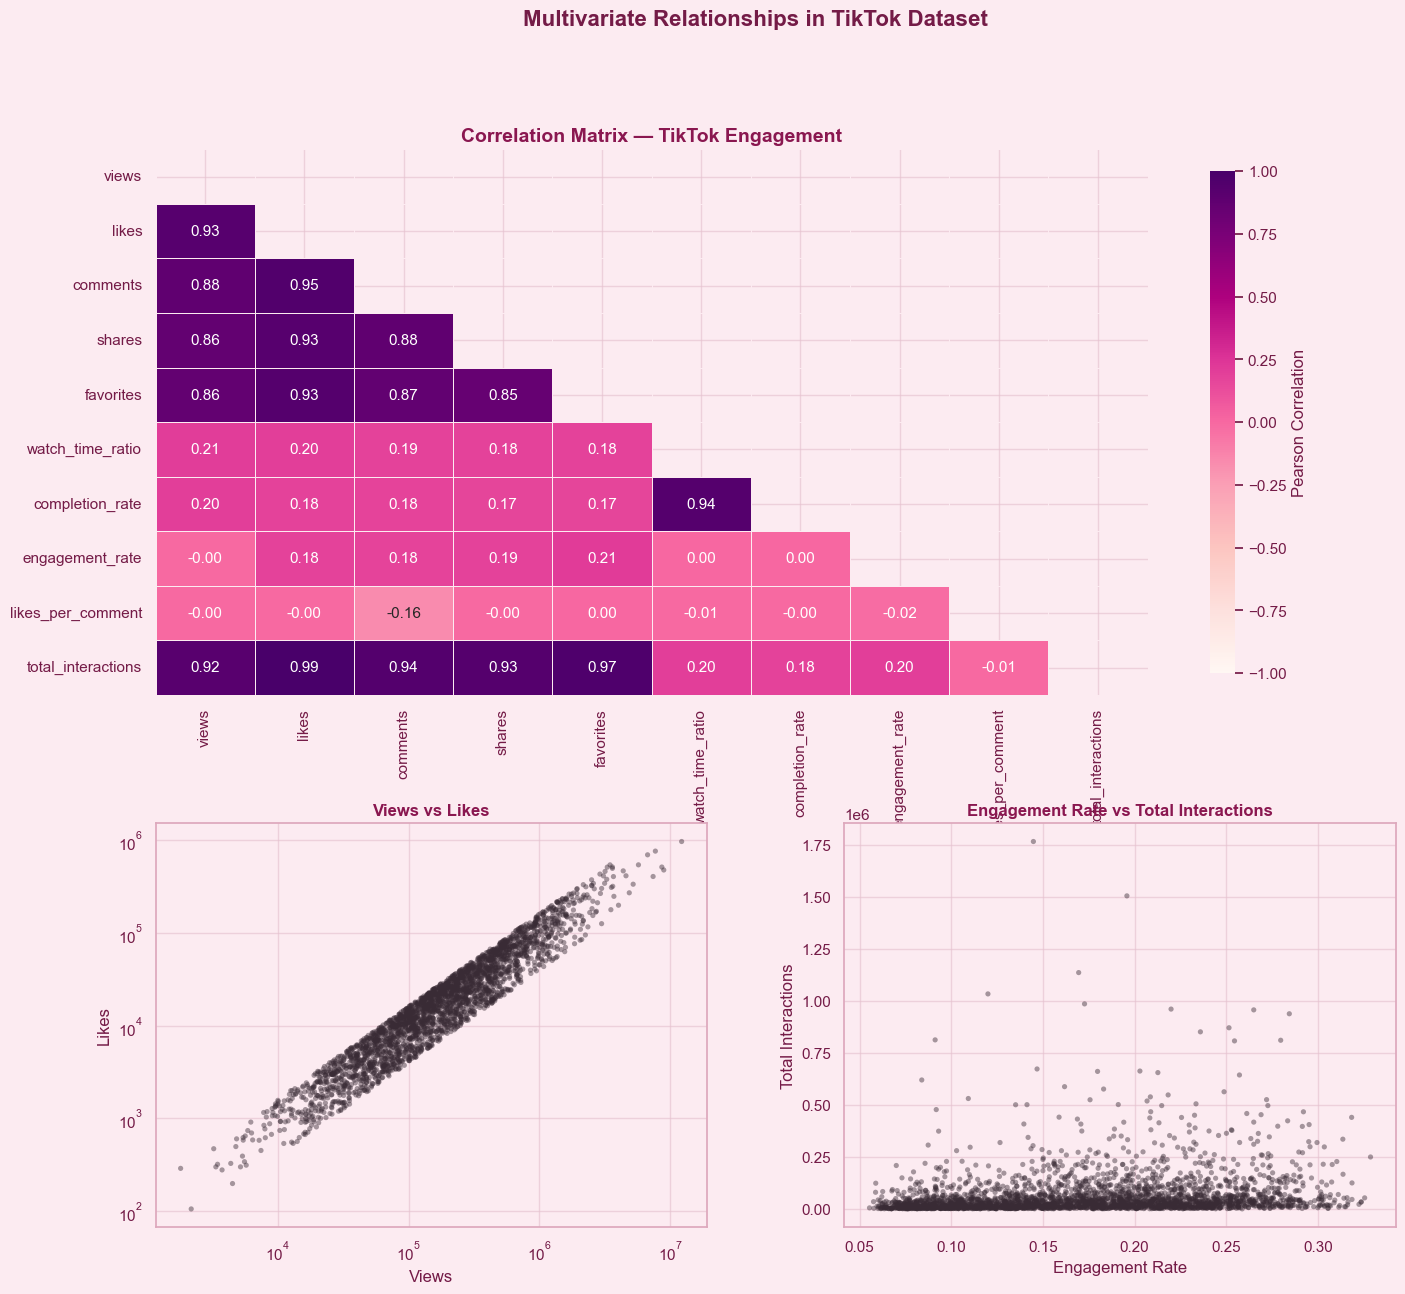

In [10]:
corr_cols = [
    "views",
    "likes",
    "comments",
    "shares",
    "favorites",
    "watch_time_ratio",
    "completion_rate",
    "engagement_rate",
    "likes_per_comment",
    "total_interactions"
]

available_cols = [col for col in corr_cols if col in data.columns]

corr_data = (
    data[available_cols]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

corr = corr_data.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))


sns.set_theme(style="whitegrid")

plt.rcParams.update({
    "figure.facecolor": "#FCEBF1",
    "axes.facecolor": "#FCEBF1",
    "axes.edgecolor": "#DDA8BC",
    "axes.labelcolor": "#741B47",
    "axes.titlecolor": "#8A1750",
    "xtick.color": "#741B47",
    "ytick.color": "#741B47",
    "text.color": "#741B47",
    "grid.color": "#E6C2D0",
    "grid.alpha": 0.65,
    "font.size": 11
})

fig = plt.figure(figsize=(16,14), facecolor="#FCEBF1")

gs = fig.add_gridspec(
    2,
    2,
    height_ratios=[1.35,1],
    hspace=0.27,
    wspace=0.25
)

ax_h = fig.add_subplot(gs[0,:])
ax_l = fig.add_subplot(gs[1,0])
ax_r = fig.add_subplot(gs[1,1])

sns.heatmap(
    corr,
    mask=mask,
    cmap="RdPu",
    vmin=-1,
    vmax=1,
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.7,
    linecolor="#FCEBF1",
    cbar=True,
    cbar_kws={
        "label":"Pearson Correlation",
        "shrink":0.92
    },
    ax=ax_h
)

ax_h.set_title(
    "Correlation Matrix — TikTok Engagement",
    fontsize=14,
    fontweight="bold"
)

sample = corr_data.sample(
    min(3000,len(corr_data)),
    random_state=42
)
ax_l.scatter(
    sample["views"],
    sample["likes"],
    color="#392B35",
    s=14,
    alpha=0.45,
    edgecolors="none"
)

ax_l.set_xscale("log")
ax_l.set_yscale("log")

ax_l.set_title("Views vs Likes", fontweight="bold")
ax_l.set_xlabel("Views")
ax_l.set_ylabel("Likes")

# Engagement
ax_r.scatter(
    sample["engagement_rate"],
    sample["total_interactions"],
    color="#392B35",
    s=14,
    alpha=0.45,
    edgecolors="none"
)

ax_r.set_title(
    "Engagement Rate vs Total Interactions",
    fontweight="bold"
)

ax_r.set_xlabel("Engagement Rate")
ax_r.set_ylabel("Total Interactions")

for ax in [ax_h, ax_l, ax_r]:
    for spine in ax.spines.values():
        spine.set_color("#DDA8BC")

fig.suptitle(
    "Multivariate Relationships in TikTok Dataset",
    fontsize=16,
    fontweight="bold",
    color="#741B47"
)

plt.tight_layout()

plt.savefig(
    "tiktok_multivariate_relationships.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="#FCEBF1"
)

plt.show()

# Feature Selection

In [11]:
features = [
    "category",
    "region",
    "language",
    "duration_seconds",
    "creator_followers",
    "creator_total_likes",
    "creator_verified",
    "account_age_days",
    "upload_hour",
    "upload_weekday",
    "hashtags_count",
    "caption_length",
    "sound_popularity",
    "effect_used",
    "posting_frequency_week"
]

x = data[features]

y = data["trend_level"]

# Train-Test Split


In [12]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

# Model Initialization

In [13]:
from xgboost import XGBClassifier

model = XGBClassifier(
    objective="multi:softprob",
    num_class=3,

    n_estimators=500,
    learning_rate=0.03,
    max_depth=6,

    min_child_weight=2,
    gamma=0.2,

    subsample=0.85,
    colsample_bytree=0.85,

    reg_alpha=0.5,
    reg_lambda=2,

    random_state=42,
    eval_metric="mlogloss"
)

In [14]:
model.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.85, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=0.2,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=2, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None, num_class=3, ...)

In [15]:
y_pred = model.predict(x_test)

In [16]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

print("Accuracy :", accuracy_score(y_test, y_pred))

print()

print(classification_report(y_test, y_pred))

Accuracy : 0.801

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        14
           1       0.81      0.82      0.82      1071
           2       0.79      0.79      0.79       915

    accuracy                           0.80      2000
   macro avg       0.53      0.54      0.54      2000
weighted avg       0.80      0.80      0.80      2000



/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  

                   Feature  Importance
12        sound_popularity    0.473921
7         account_age_days    0.040588
4        creator_followers    0.039760
6         creator_verified    0.039103
5      creator_total_likes    0.038823
3         duration_seconds    0.038562
11          caption_length    0.038365
10          hashtags_count    0.037680
0                 category    0.037674
8              upload_hour    0.037112
14  posting_frequency_week    0.036701
1                   region    0.036590
9           upload_weekday    0.036423
2                 language    0.036402
13             effect_used    0.032297


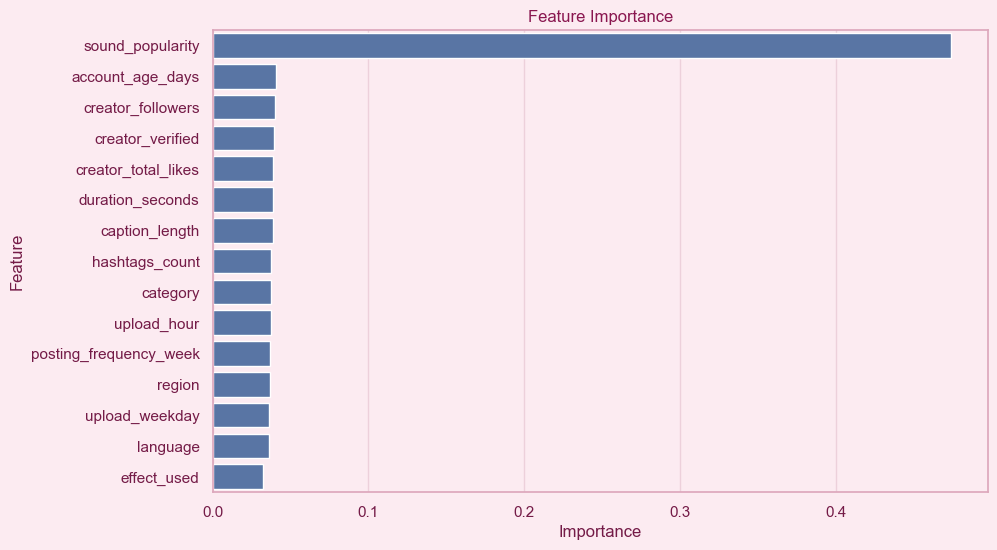

In [17]:
importance = model.feature_importances_

feature_importance = (
    pd.DataFrame({
        "Feature": x.columns,
        "Importance": importance
    })
    .sort_values("Importance", ascending=False)
)

print(feature_importance)

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")
plt.show()